# DENETİMSİZ ÖĞRENME ALGORİTMALARI KARŞILAŞTIRMASI
## Customer Segmentation - Kredi Kartı Müşteri Analizi

Bu notebook'ta aşağıdaki denetimsiz öğrenme algoritmaları detaylı olarak incelenecek ve karşılaştırılacaktır:

1. **K-Means Clustering**
2. **Hierarchical Clustering (Agglomerative)**
3. **DBSCAN (Density-Based Spatial Clustering)**
4. **Gaussian Mixture Models (GMM)**
5. **Principal Component Analysis (PCA)** - Boyut indirgeme
6. **t-SNE (t-Distributed Stochastic Neighbor Embedding)** - Görselleştirme

---
## 1. GEREKLİ KÜTÜPHANELERİN YÜKLENMESİ

In [1]:
# Temel kutuphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# On isleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Kumeleme algoritmalari
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Boyut indirgeme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Degerlendirme metrikleri
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Kutuphaneler basariyla yuklendi.')

Kutuphaneler basariyla yuklendi.


---
## 2. VERİ SETİNİN YÜKLENMESİ VE KEŞFİ

In [2]:
# Veri setini yukle
df = pd.read_csv('Customer Data.csv')
print(f'Veri seti boyutu: {df.shape}')
print(f'Sutun sayisi: {len(df.columns)}')
print(f'Satir sayisi: {len(df)}')

Veri seti boyutu: (8950, 18)
Sutun sayisi: 18
Satir sayisi: 8950


In [3]:
# Ilk 5 satir
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Veri seti bilgisi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
# Istatistiksel ozet
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
# Eksik degerler
print('Eksik deger sayilari:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nToplam eksik deger: {df.isnull().sum().sum()}')

Eksik deger sayilari:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Toplam eksik deger: 314


---
## 3. VERİ ÖN İŞLEME

In [7]:
# CUST_ID sutununu indeks olarak ata
df.set_index('CUST_ID', inplace=True)

# Eksik degerleri sutun ortalamasi ile doldur
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

print(f'Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}')
print(f'\nVeri seti boyutu: {df_imputed.shape}')

Eksik deger kaldi mi: 0

Veri seti boyutu: (8950, 17)


In [8]:
# Olceklendirme (Standardizasyon)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=df_imputed.columns, index=df_imputed.index)

print('Olceklendirilmis veri (ilk 5 satir):')
X_scaled.head()

Olceklendirilmis veri (ilk 5 satir):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
C10003,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
C10004,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
C10005,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


---
## 4. K-Means KÜMELEME ALGORİTMASI

### Algoritma Açıklaması

**K-Means**, veri setini K adet kümeye ayıran, merkez tabanlı bir kümeleme algoritmasıdır.

**Çalışma Prensipleri:**
1. K adet başlangıç merkezi (centroid) rastgele seçilir.
2. Her veri noktası en yakın merkeze atanır.
3. Her kümenin yeni merkezi, o kümedeki noktaların ortalaması alınarak güncellenir.
4. 2. ve 3. adımlar merkezler değişmeyene kadar tekrarlanır.

**Hiperparametreler:**
- `n_clusters`: Küme sayısı (K)
- `init`: Başlangıç merkez seçim yöntemi ('k-means++', 'random')
- `n_init`: Farklı başlangıçlarla çalıştırma sayısı
- `max_iter`: Maksimum iterasyon sayısı

**Küme Sayısını Belirleme Yöntemleri:**
- **Elbow Metodu**: K değerine karşılık inertia (WCSS) grafiği çizilir, dirsek noktası seçilir.
- **Silhouette Skoru**: Kümeleme kalitesini -1 ile 1 arasında değerlendirir.
- **Davies-Bouldin İndeksi**: Kümeler arası benzerliği ölçer, düşük değer iyidir.

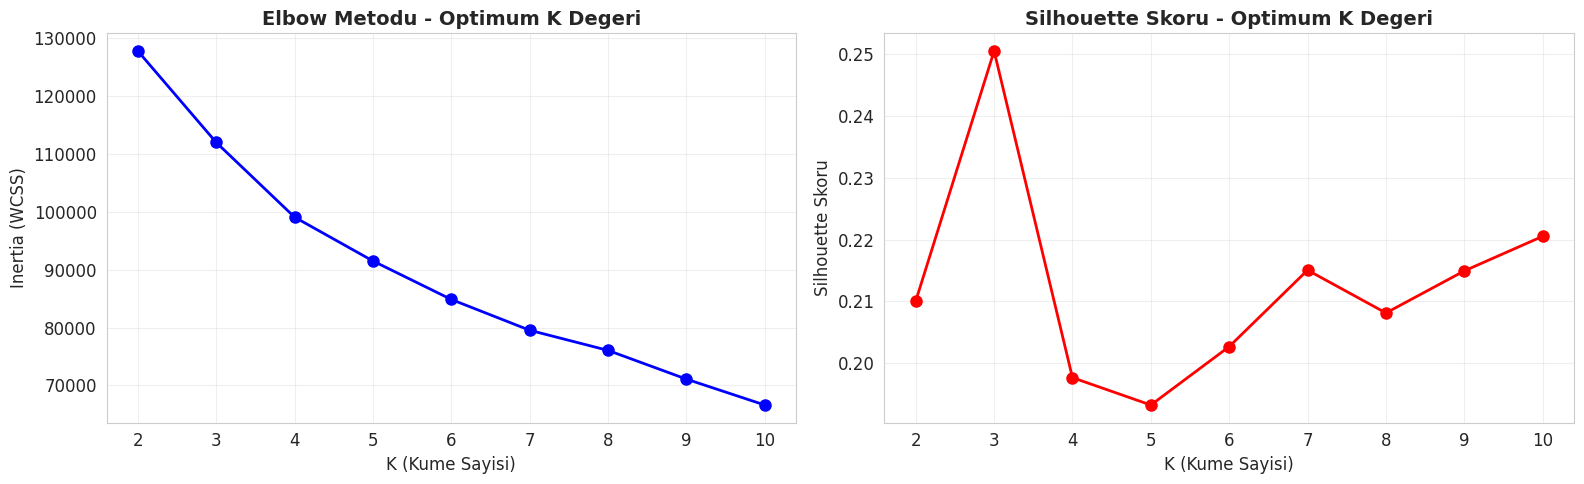

En iyi silhoutte skoru: 0.2506
Optimum K degeri: 3


In [9]:
# Elbow metodu ile optimum K degerini bulma
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [10]:
# Optimum K ile K-Means modelini egit
optimal_k = 4  # Elbow ve silhouette analizine gore
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 4
Silhouette Skoru: 0.1976
Davies-Bouldin Indeksi: 1.5752
Calinski-Harabasz Skoru: 1597.5222

Kume dagilimi:
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


In [11]:
# K-Means kumelerinin ozetleri
df['KMeans_Cluster'] = kmeans_labels
cluster_summary = df.groupby('KMeans_Cluster').mean().round(2)
print('K-Means Kume Profilleri:')
cluster_summary

K-Means Kume Profilleri:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,646.02,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1985.04,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2020.80,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.40,974.51,569.00,0.08,11.45


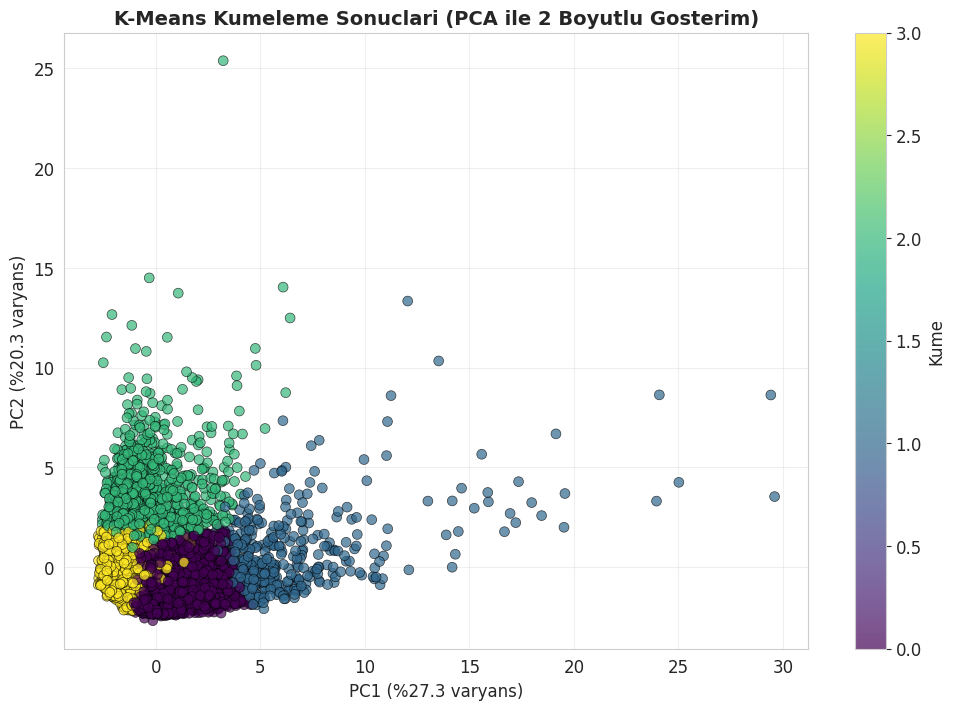

In [12]:
# PCA ile K-Means gorsellestirmesi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', 
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
## 5. HİYERARŞİK KÜMELEME (Agglomerative Clustering)

### Algoritma Açıklaması

**Hiyerarşik Kümeleme**, veri noktalarını hiyerarşik bir yapıda kümeleyen algoritmadır. İki yaklaşımı vardır:
- **Agglomerative (Aşağıdan-Yukarı)**: Her nokta kendi kümesidir, benzer kümeler birleşir.
- **Divisive (Yukarıdan-Aşağı)**: Tüm noktalar tek kümededir, bölünerek ayrışır.

**Çalışma Prensipleri (Agglomerative):**
1. Her veri noktası ayrı bir küme olarak başlar.
2. En benzer iki küme birleştirilir.
3. 2. adım istenen küme sayısına ulaşılana kadar tekrarlanır.

**Bağlantı Yöntemleri (Linkage):**
- `ward`: Varyans minimizasyonu (varsayılan)
- `complete`: Kümeler arası maksimum mesafe
- `average`: Kümeler arası ortalama mesafe
- `single`: Kümeler arası minimum mesafe

**Dendrogram**: Hiyerarşik yapıyı gösteren ağaç diyagramı.

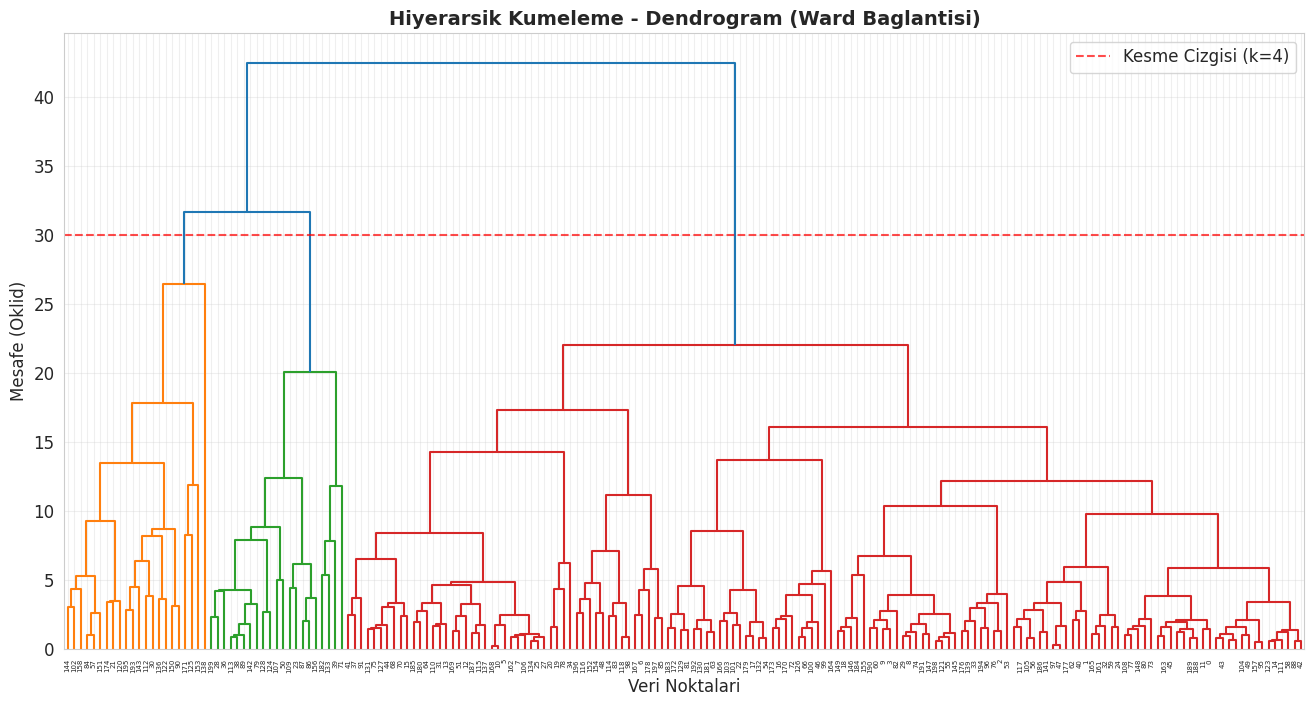

In [13]:
# Dendrogram (Baglanti yontemi: ward)
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending', 
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kesme Cizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Agglomerative Clustering modeli
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 4
Baglanti yontemi: ward
Silhouette Skoru: 0.1547
Davies-Bouldin Indeksi: 1.7762
Calinski-Harabasz Skoru: 1255.6049

Kume dagilimi:
0     487
1    4668
2     864
3    2931
Name: count, dtype: int64


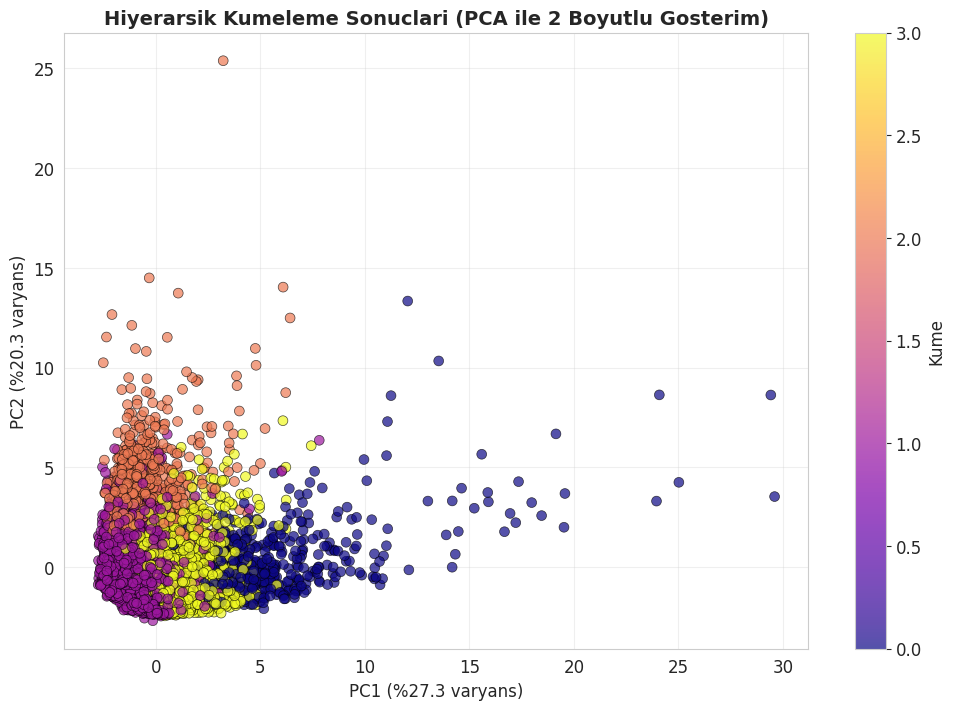

In [15]:
# Hiyerarsik kumelerin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma', 
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
## 6. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

### Algoritma Açıklaması

**DBSCAN**, yoğunluk tabanlı bir kümeleme algoritmasıdır. Kümeleri, yüksek yoğunluklu bölgeler olarak tanımlar.

**Çalışma Prensipleri:**
1. Her nokta için epsilon (eps) yarıçapındaki komşu sayısı hesaplanır.
2. **Çekirdek Nokta**: min_samples'den fazla komşusu olan nokta.
3. **Sınır Noktası**: Çekirdek noktaya yakın ama yeterli komşusu olmayan nokta.
4. **Gürültü Noktası**: Hiçbir kümeye ait olmayan nokta (etiket = -1).
5. Yoğunlukla bağlantılı noktalar aynı kümeyi oluşturur.

**Hiperparametreler:**
- `eps`: Komşuluk yarıçapı
- `min_samples`: Çekirdek nokta için minimum komşu sayısı

**Avantajları:**
- Küme sayısını önceden belirtmeye gerek yoktur
- Aykırı değerleri (gürültü) tespit edebilir
- Karmaşık şekilli kümeleri bulabilir

**Dezavantajları:**
- Farklı yoğunluktaki kümeleri bulmakta zorlanır
- eps parametresine duyarlıdır

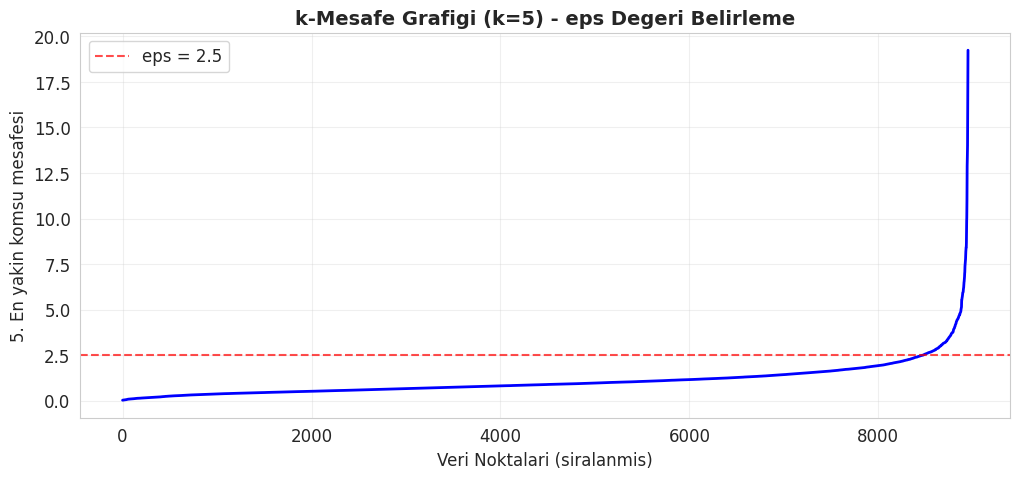

In [16]:
# DBSCAN icin eps degeri belirleme (k-distance grafigi)
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# DBSCAN modeli
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 2.5, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kumeleme Sonuclari:
eps: 2.5, min_samples: 5
Olusan kume sayisi: 1
Gurultu (aykiri deger) sayisi: 341
Gurultu orani: 3.81%

Kume dagilimi:
-1     341
 0    8609
Name: count, dtype: int64


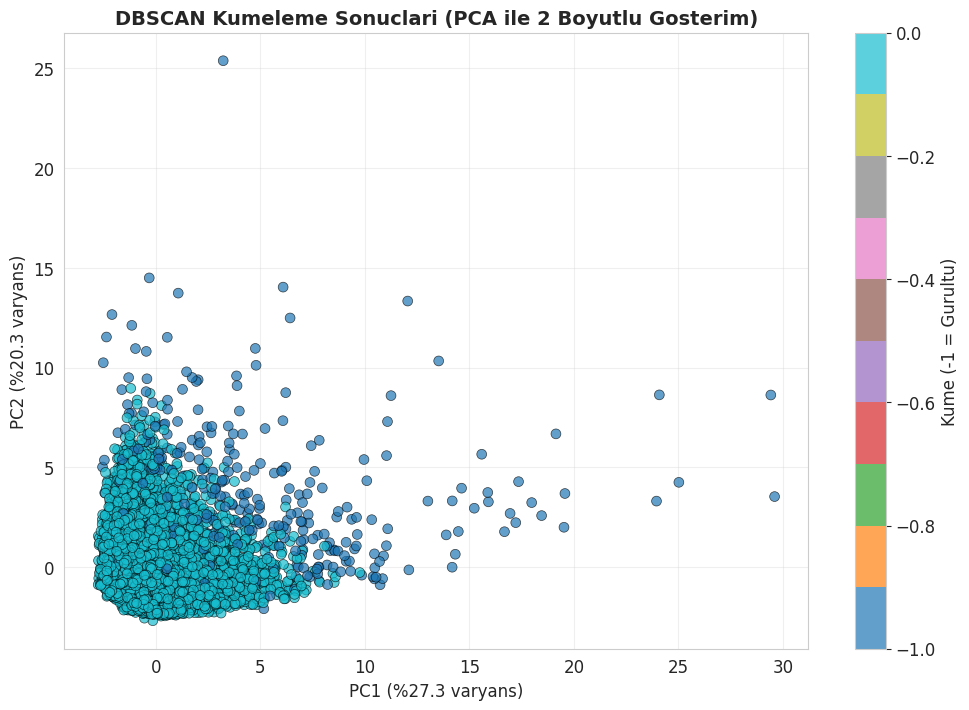

In [18]:
# DBSCAN kumelerinin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', 
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
## 7. GAUSSIAN MIXTURE MODELS (GMM)

### Algoritma Açıklaması

**GMM**, verinin birden çok Gauss (normal) dağılımının karışımından oluştuğunu varsayan olasılıksal bir modeldir.

**Çalışma Prensipleri:**
1. Verinin K adet Gauss dağılımının karışımı olduğu varsayılır.
2. **EM (Expectation-Maximization)** algoritması ile parametreler tahmin edilir:
   - **E-Step**: Her noktanın her kümeye ait olma olasılığı hesaplanır.
   - **M-Step**: Gauss parametreleri (ortalama, kovaryans, ağırlık) güncellenir.
3. Yakınsayana kadar 2. adım tekrarlanır.

**Hiperparametreler:**
- `n_components`: Bileşen (küme) sayısı
- `covariance_type`: Kovaryans tipi ('full', 'tied', 'diag', 'spherical')
- `max_iter`: Maksimum iterasyon sayısı

**Avantajları:**
- Olasılıksal atama yapar (yumuşak kümeleme)
- K-Means'ten daha esnektir (eliptik kümeler)
- Her noktanın kümelere ait olma olasılığını verir

In [19]:
# GMM modeli
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42, max_iter=200)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

print('Gaussian Mixture Model Sonuclari:')
print(f'Bilesen sayisi: {optimal_k}')
print(f'Kovaryans tipi: full')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, gmm_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, gmm_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, gmm_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(gmm_labels).value_counts().sort_index())

Gaussian Mixture Model Sonuclari:
Bilesen sayisi: 4
Kovaryans tipi: full
Silhouette Skoru: 0.0733
Davies-Bouldin Indeksi: 2.7770
Calinski-Harabasz Skoru: 738.5114

Kume dagilimi:
0    2077
1    1697
2    2484
3    2692
Name: count, dtype: int64


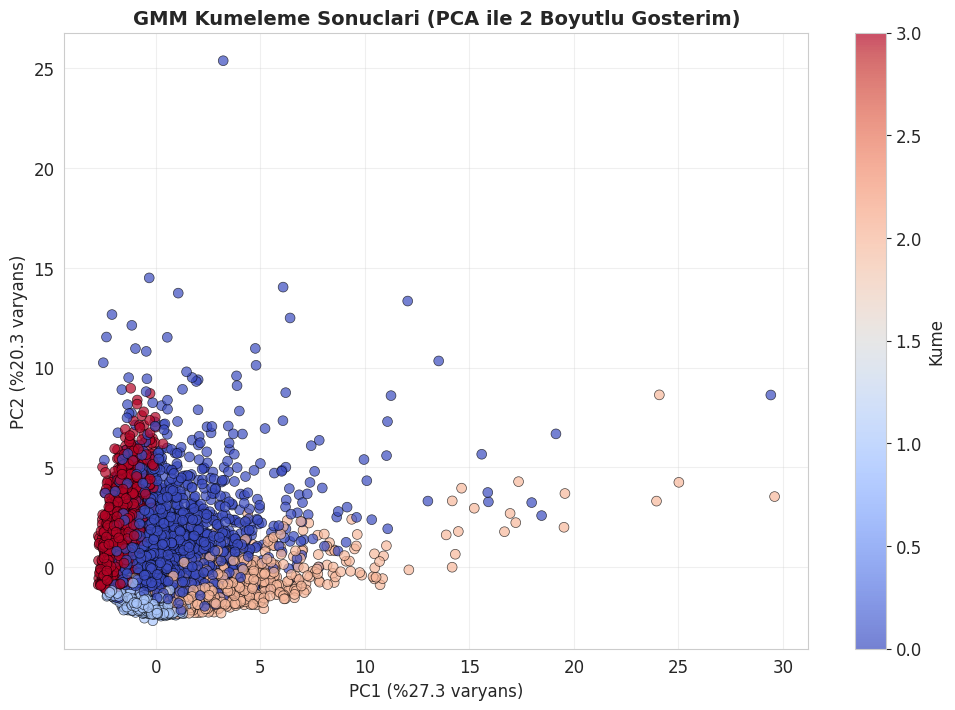

In [20]:
# GMM kumelerinin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='coolwarm', 
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('GMM Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

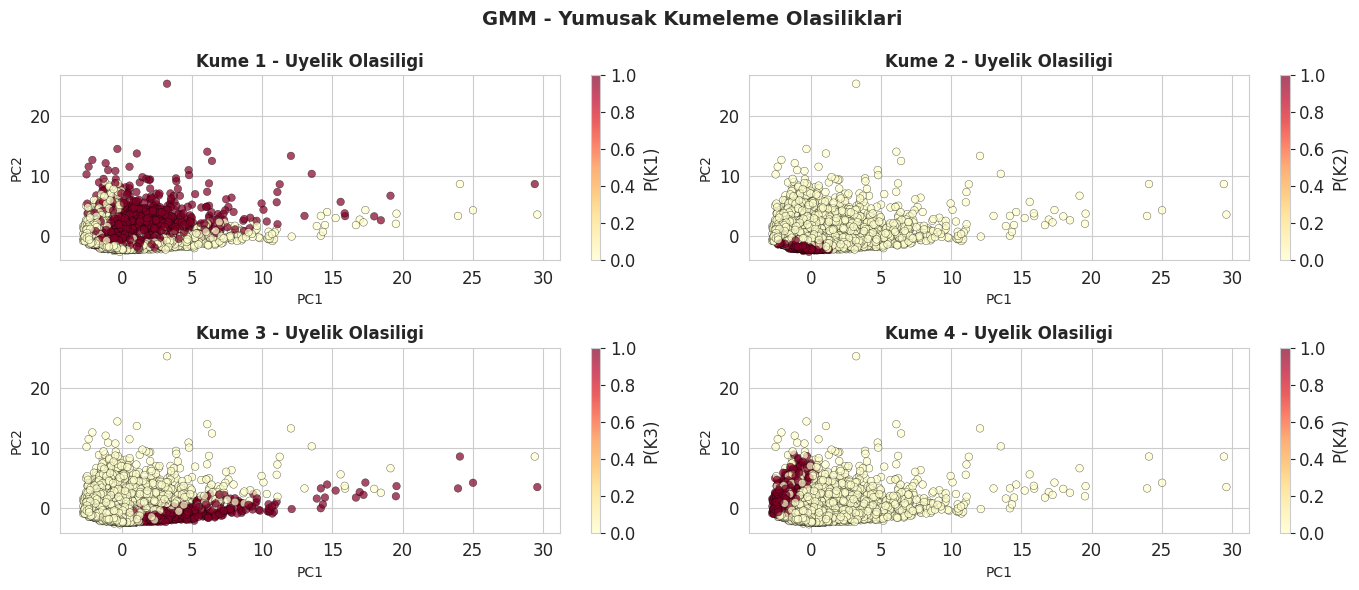

In [21]:
# GMM olasilik atamalarinin gorsellestirmesi
plt.figure(figsize=(14, 6))
for i in range(optimal_k):
    plt.subplot(2, 2, i+1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_probs[:, i], 
                          cmap='YlOrRd', alpha=0.7, s=30, edgecolors='k', linewidth=0.3)
    plt.colorbar(scatter, label=f'P(K{i+1})')
    plt.title(f'Kume {i+1} - Uyelik Olasiligi', fontsize=12, fontweight='bold')
    plt.xlabel('PC1', fontsize=10)
    plt.ylabel('PC2', fontsize=10)

plt.suptitle('GMM - Yumusak Kumeleme Olasiliklari', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. PRINCIPAL COMPONENT ANALYSIS (PCA)

### Algoritma Açıklaması

**PCA**, yüksek boyutlu veriyi daha düşük boyutlu bir uzaya projekte eden, boyut indirgeme ve görselleştirme tekniğidir.

**Çalışma Prensipleri:**
1. Verinin ortalaması merkeze alınır.
2. Kovaryans matrisi hesaplanır.
3. Özdeğer (eigenvalue) ve özvektör (eigenvector) hesaplanır.
4. En büyük özdeğere sahip özvektörler **Temel Bileşenler (PC)** olarak seçilir.
5. Veri, seçilen temel bileşenlere projekte edilir.

**Kullanım Alanları:**
- Görselleştirme (2D/3D)
- Gürültü azaltma
- Hızlandırma (boyut sayısını azaltarak)
- Çoklu bağlantı (multicollinearity) problemini çözme

**Önemli Kavramlar:**
- `explained_variance_ratio_`: Her bileşenin açıkladığı varyans oranı
- `components_`: Temel bileşenlerin yönleri (loading scores)

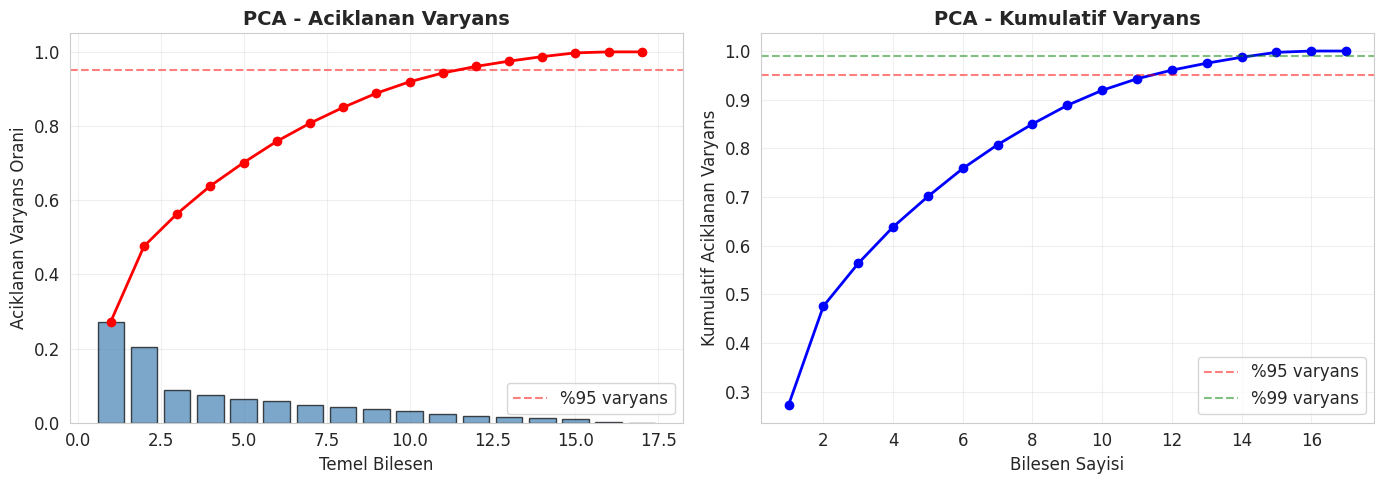

%95 varyans icin gereken bilesen sayisi: 12
Ilk 2 bilesenin acikladigi varyans: 47.59%


In [22]:
# PCA - Aciklanan varyans analizi
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

# Aciklanan varyans
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, 
        alpha=0.7, color='steelblue', edgecolor='k')
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-', linewidth=2, markersize=6)
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='%95 varyans')
plt.xlabel('Temel Bilesen', fontsize=12)
plt.ylabel('Aciklanan Varyans Orani', fontsize=12)
plt.title('PCA - Aciklanan Varyans', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2, markersize=6)
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='%95 varyans')
plt.axhline(y=0.99, color='g', linestyle='--', alpha=0.5, label='%99 varyans')
plt.xlabel('Bilesen Sayisi', fontsize=12)
plt.ylabel('Kumulatif Aciklanan Varyans', fontsize=12)
plt.title('PCA - Kumulatif Varyans', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'%95 varyans icin gereken bilesen sayisi: {n_components_95}')
print(f'Ilk 2 bilesenin acikladigi varyans: {cumulative_variance[1]*100:.2f}%')

In [23]:
# PCA loading matrix (degisken katkilari)
loadings = pd.DataFrame(
    pca_full.components_[:4].T,
    index=X_scaled.columns,
    columns=[f'PC{i+1}' for i in range(4)]
)

print('PCA Loading Matrisi (Ilk 4 Bilesen):')
loadings

PCA Loading Matrisi (Ilk 4 Bilesen):


,PC1,PC2,PC3,PC4
BALANCE,0.101077,0.403957,0.160075,0.283454
BALANCE_FREQUENCY,0.120043,0.130537,0.420630,0.149742
PURCHASES,0.411642,0.041038,-0.257903,0.039111
ONEOFF_PURCHASES,0.346407,0.062872,-0.392115,0.078155
INSTALLMENTS_PURCHASES,0.336814,-0.018533,0.110488,-0.051130
CASH_ADVANCE,-0.023343,0.439242,0.027345,-0.254586
PURCHASES_FREQUENCY,0.321493,-0.190780,0.374691,-0.188975
ONEOFF_PURCHASES_FREQUENCY,0.294633,-0.017924,-0.115131,0.027465
PURCHASES_INSTALLMENTS_FREQUENCY,0.274710,-0.178601,0.473409,-0.215002
CASH_ADVANCE_FREQUENCY,-0.089139,0.434082,0.109072,-0.264228


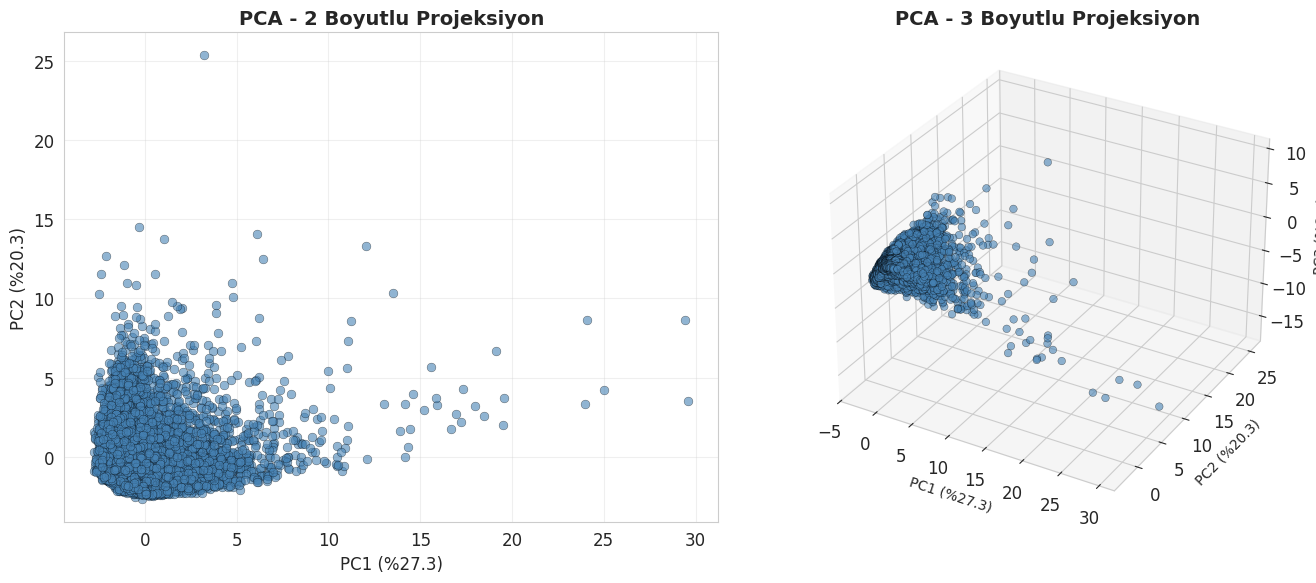

In [24]:
# PCA - 2 Boyutlu gorsellestirme
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=40, c='steelblue', edgecolors='k', linewidth=0.3)
plt.title('PCA - 2 Boyutlu Projeksiyon', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f})', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f})', fontsize=12)
plt.grid(True, alpha=0.3)

# 3D gorsellestirme
ax = plt.subplot(1, 2, 2, projection='3d')
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
           alpha=0.6, s=30, c='steelblue', edgecolors='k', linewidth=0.3)
ax.set_title('PCA - 3 Boyutlu Projeksiyon', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 (%{pca_3d.explained_variance_ratio_[0]*100:.1f})', fontsize=10)
ax.set_ylabel(f'PC2 (%{pca_3d.explained_variance_ratio_[1]*100:.1f})', fontsize=10)
ax.set_zlabel(f'PC3 (%{pca_3d.explained_variance_ratio_[2]*100:.1f})', fontsize=10)

plt.tight_layout()
plt.show()

---
## 9. t-SNE (t-Distributed Stochastic Neighbor Embedding)

### Algoritma Açıklaması

**t-SNE**, yüksek boyutlu veriyi 2 veya 3 boyuta indirgeyerek görselleştirme için kullanılan bir manifold öğrenme tekniğidir.

**Çalışma Prensipleri:**
1. Yüksek boyutlu uzayda veri noktaları arasındaki benzerlikler (Gauss dağılımı ile) hesaplanır.
2. Düşük boyutlu uzayda noktalar arası benzerlikler (t-dağılımı ile) hesaplanır.
3. İki dağılım arasındaki **KL diverjansı (Kullback-Leibler divergence)** minimize edilir.
4. Gradient descent ile optimizasyon yapılır.

**Hiperparametreler:**
- `n_components`: Hedef boyut sayısı (genelde 2 veya 3)
- `perplexity`: Komşuluk dengesi (5-50 arası, genelde 30)
- `learning_rate`: Öğrenme hızı
- `n_iter`: Iterasyon sayısı

**PCA vs t-SNE:**
- PCA doğrusal (linear) bir dönüşümdür, t-SNE doğrusal değildir (non-linear).
- PCA varyansı maksimize eder, t-SNE benzerlikleri korur.
- PCA küresel yapıyı korur, t-SNE yerel yapıyı korur.
- t-SNE hesaplama açısından daha yoğundur.

In [25]:
# t-SNE gorsellestirmesi (PCA ve K-Means etiketleri ile karsilastirma)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30, c='steelblue', edgecolors='k', linewidth=0.3)
plt.title('t-SNE - 2 Boyutlu Gorsellestirme', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Boyut 1', fontsize=12)
plt.ylabel('t-SNE Boyut 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='viridis', 
                      alpha=0.7, s=30, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Kume')
plt.title('t-SNE - K-Means Kume Etiketleri', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Boyut 1', fontsize=12)
plt.ylabel('t-SNE Boyut 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
# t-SNE - Tum kumeleme sonuclarinin karsilastirmasi
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_data = [
    (kmeans_labels, 'K-Means', 'viridis'),
    (agg_labels, 'Hiyerarsik (Agglomerative)', 'plasma'),
    (dbscan_labels, 'DBSCAN', 'tab10'),
    (gmm_labels, 'GMM', 'coolwarm'),
]

for ax, (labels, title, cmap) in zip(axes.flat[:4], plot_data):
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap=cmap, 
                         alpha=0.7, s=30, edgecolors='k', linewidth=0.3)
    ax.set_title(f't-SNE + {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    plt.colorbar(scatter, ax=ax, label='Kume')
    ax.grid(True, alpha=0.3)

# PCA karsilastirma
scatter = axes.flat[4].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                                alpha=0.7, s=30, edgecolors='k', linewidth=0.3)
axes.flat[4].set_title('PCA + K-Means', fontsize=13, fontweight='bold')
axes.flat[4].set_xlabel('PC1', fontsize=10)
axes.flat[4].set_ylabel('PC2', fontsize=10)
plt.colorbar(scatter, ax=axes.flat[4], label='Kume')
axes.flat[4].grid(True, alpha=0.3)

axes.flat[5].axis('off')

plt.suptitle('t-SNE ile Kumeleme Algoritmalarinin Karsilastirmasi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. ALGORİTMA KARŞILAŞTIRMASI

### 10.1 Performans Metrikleri Karşılaştırması

In [ ]:
# Tum algoritmalarin metriklerini karsilastir
results = []

algorithms = [
    ('K-Means', kmeans_labels, 'Evet', 'Kume merkezleri'),
    ('Hiyerarsik (Agg.)', agg_labels, 'Evet', 'Dendrogram'),
    ('DBSCAN', dbscan_labels, 'Hayir (-1)', 'YoGunluk'),
    ('GMM', gmm_labels, 'Evet (olasiliksal)', 'Gauss dagilimi'),
]

for name, labels, predef, basis in algorithms:
    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})
    n_noise = list(labels).count(-1)
    
    sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else 'N/A'
    db = davies_bouldin_score(X_scaled, labels) if n_clusters > 1 else 'N/A'
    ch = calinski_harabasz_score(X_scaled, labels) if n_clusters > 1 else 'N/A'
    
    results.append({
        'Algoritma': name,
        'Kume Sayisi': n_clusters,
        'K Sayisi Gerekli': predef,
        'Kumeleme Temeli': basis,
        'Silhouette': f'{sil:.4f}' if sil != 'N/A' else 'N/A',
        'Davies-Bouldin': f'{db:.4f}' if db != 'N/A' else 'N/A',
        'Calinski-Harabasz': f'{ch:.2f}' if ch != 'N/A' else 'N/A',
    })

results_df = pd.DataFrame(results)
results_df

In [ ]:
# Gorsel metrik karsilastirmasi
metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
alg_names = ['K-Means', 'Hiyerarsik', 'GMM']

alg_metrics = []
for name, labels, _, _ in algorithms[:3]:  # DBSCAN haric (aykiri degerler)
    alg_metrics.append([
        silhouette_score(X_scaled, labels),
        davies_bouldin_score(X_scaled, labels),
        calinski_harabasz_score(X_scaled, labels)
    ])

alg_metrics = np.array(alg_metrics)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'coral', 'seagreen', 'gold']

for i, (metric, ax) in enumerate(zip(metrics, axes)):
    bars = ax.bar(alg_names, alg_metrics[:, i], color=colors[:3], alpha=0.8, edgecolor='k')
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Skor', fontsize=11)
    for bar, val in zip(bars, alg_metrics[:, i]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Algoritma Performans Metrikleri Karsilastirmasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Kume sayilarinin karsilastirmasi
cluster_counts = pd.DataFrame({
    'K-Means': pd.Series(kmeans_labels).value_counts().sort_index().values,
    'Hiyerarsik': pd.Series(agg_labels).value_counts().sort_index().values,
    'GMM': pd.Series(gmm_labels).value_counts().sort_index().values,
})

ax = cluster_counts.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'coral', 'seagreen'],
                         alpha=0.8, edgecolor='k', width=0.7)
plt.title('Kume Dagilimlari Karsilastirmasi', fontsize=14, fontweight='bold')
plt.xlabel('Kume', fontsize=12)
plt.ylabel('Veri Sayisi', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.legend(title='Algoritma')

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.show()

### 10.2 Algoritma Uyumluluğu (Küme Etiketleri Arası Korelasyon)

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

alg_pairs = [
    ('K-Means vs Hiyerarsik', kmeans_labels, agg_labels),
    ('K-Means vs GMM', kmeans_labels, gmm_labels),
    ('Hiyerarsik vs GMM', agg_labels, gmm_labels),
]

comparison_df = pd.DataFrame({
    'Algoritma Cifti': [p[0] for p in alg_pairs],
    'Adjusted Rand Index': [adjusted_rand_score(p[1], p[2]) for p in alg_pairs],
    'Normalized Mutual Info': [normalized_mutual_info_score(p[1], p[2]) for p in alg_pairs],
})

comparison_df

### 10.3 Özet Karşılaştırma Tablosu

| Özellik | K-Means | Hiyerarşik | DBSCAN | GMM |
|---------|---------|------------|--------|----|
| **Küme Sayısı** | Önceden belirtilir | Önceden belirtilir | Otomatik | Önceden belirtilir |
| **Küme Şekli** | Dairesel | Esnek (linkage'a bağlı) | Her şekil | Eliptik |
| **Aykırı Değer** | Duyarlı | Duyarlı | Tespit eder | Duyarlı |
| **Ölçek Hassasiyeti** | Yüksek | Yüksek | Yüksek | Yüksek |
| **Hesaplama Karmaşıklığı** | O(n·k·d) | O(n³) | O(n²) | O(n·k·d²) |
| **Kümeleme Türü** | Sert | Sert | Sert | Yumuşak (olasılıksal) |
| **Yorumlanabilirlik** | Yüksek | Yüksek | Orta | Orta |
| **Büyük Veri** | İyi | Kötü | Orta | İyi |

---
## 11. SONUÇ VE DEĞERLENDİRME

### Algoritmaların Güçlü ve Zayıf Yönleri:

**1. K-Means Clustering**
- **Güçlü:** Basit, hızlı, büyük veri için uygun, yorumlanabilirliği yüksek
- **Zayıf:** Küme sayısı önceden belirtilmeli, dairesel kümeler varsayar, aykırı değerlere duyarlı

**2. Hierarchical Clustering**
- **Güçlü:** Dendrogram ile görselleştirme, küme sayısı sonradan belirlenebilir
- **Zayıf:** Yüksek hesaplama maliyeti (O(n³)), büyük veri için uygun değil

**3. DBSCAN**
- **Güçlü:** Küme sayısı gerekmez, aykırı değerleri tespit eder, karmaşık şekilleri bulur
- **Zayıf:** Farklı yoğunluklardaki kümelerde başarısız, eps parametresine çok duyarlı

**4. Gaussian Mixture Models**
- **Güçlü:** Olasılıksal atama, esnek küme şekilleri, yumuşak kümeleme
- **Zayıf:** Yavaş (yüksek boyutlu veride), fazla uyuma (overfitting) yatkın

### Veri Seti Özelinde Değerlendirme:
- Müşteri segmentasyonu için en uygun algoritma **K-Means** veya **GMM**'dir.
- K-Means basitliği ve hızı sayesinde tercih edilirken, GMM olasılıksal yaklaşımıyla daha esnektir.
- Hiyerarşik kümeleme dendrogram görselleştirmesi sayesinde segment sayısını belirlemede yardımcı olur.
- DBSCAN aykırı müşterileri (anomali) tespit etmek için kullanılabilir.
- PCA ve t-SNE, yüksek boyutlu müşteri verisini görselleştirmek için etkili araçlardır.

In [ ]:
print('='*60)
print('DENETIMSIZ OGRENME ALGORITMALARI KARSILASTIRMASI TAMAMLANDI')
print('='*60)
print(f'\nKullanilan algoritmalar:')
print('  1. K-Means Clustering')
print('  2. Hierarchical Clustering (Agglomerative)')
print('  3. DBSCAN')
print('  4. Gaussian Mixture Models (GMM)')
print('  5. PCA (Boyut Indirgeme)')
print('  6. t-SNE (Gorsellestirme)')
print(f'\nVeri seti: Customer Data.csv')
print(f'Ornek sayisi: {len(df)}')